### UTS TEXT MINING 2702242171 - Vanessa Santoso

#### SCRAPPING

Karena soal diminta untuk mencari review playstore dari sebuah game, maka saya akan men-download google-play-scrapper untuk melakukan scrapping dari google playstore. Hasilnya nanti akan dibuat menjadi csv untuk dilakukan analisis

In [13]:
%pip install google-play-scraper
%pip install seaborn
%pip install wordcloud
%pip install gensim
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [14]:
from google_play_scraper import app, reviews
import pandas as pd

review, _ = reviews(
    'com.devsisters.ck',
    lang='en',
    country='us',
    count=2000
)

In [15]:
df = pd.DataFrame(review)
df = df[['content', 'score']]
df.columns = ['review', 'rating']
df.to_csv('cookie_run_kingdom.csv', index=False)

#### 2. Exploratory Data Analysis

Sebelum dilakukan pemrosesan data, maka data harus dianalisis dulu seperti apa bentuknya. Rating berapa yang paling banyak dan kata apa saja yang menjadi mayoritas

rating
5    1607
4     173
1     118
3      72
2      30
Name: count, dtype: int64


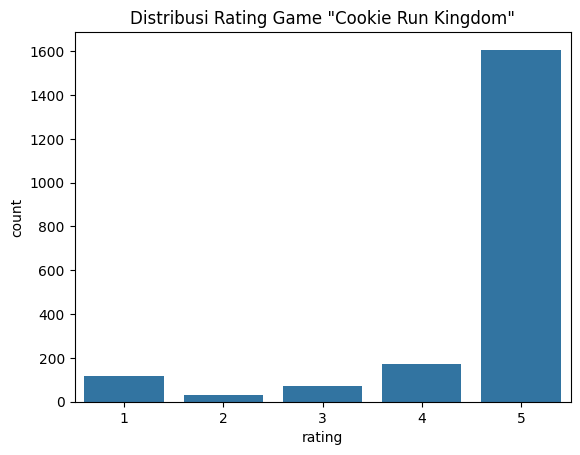

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='rating', data=df)
plt.title('Distribusi Rating Game "Cookie Run Kingdom"')
print(df['rating'].value_counts())

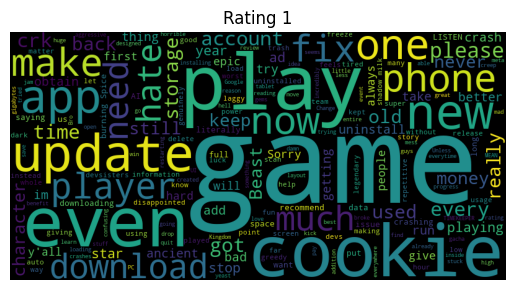

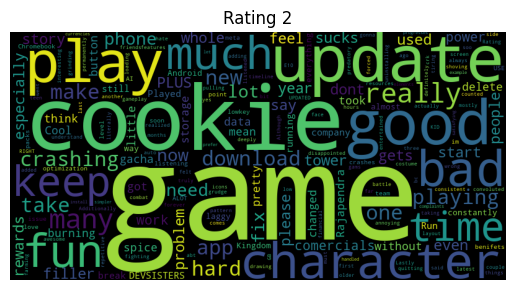

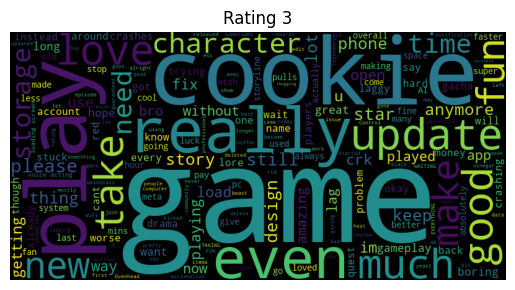

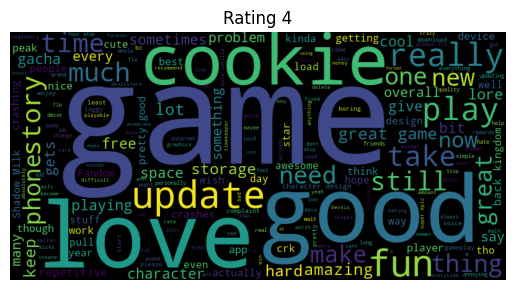

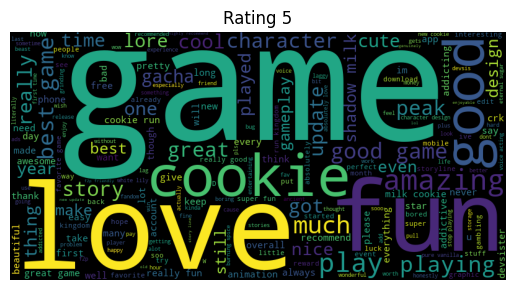

In [17]:
from wordcloud import WordCloud

for i in range(1,6):
    text = " ".join(df[df['rating']==i]['review'])
    wc = WordCloud(width=800, height=400).generate(text)
    
    plt.imshow(wc)
    plt.title(f"Rating {i}")
    plt.axis('off')
    plt.show()

#### 3. PREPROCESSING

Pada tahap ini, kita melakukan preprocessing dengan beberapa cara agar lebih baik dicerna oleh model. Beberapa tahapannya diantaranya adalah menjadikan semua kata"nya lowercase serta menghilangkan kata" yang mengandung huruf diluar alfabet dan menghilangkan stopwords

In [18]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    cleaned_tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Hasil Preprocessing:")
print(df[['review', 'cleaned_review']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vanessa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Vanessa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Hasil Preprocessing:
                                              review  \
0                        VERY BAD GAME EVILLLL GAMEE   
1  This is a great game I have been playing this ...   
2                   I take it all back. I love crk 🥹   
3                nice game! but fix some of the bugs   
4                        Really good game in general   

                                      cleaned_review  
0                               bad game evilll game  
1  great game play game week storylin charact muc...  
2                                 take back love crk  
3                                  nice game fix bug  
4                             realli good game gener  


#### 4. TEXT REPRESENTATION

Representasi Teks digunakan untuk mengubah kata menjadi nilai numerik agar bisa dihitung secara statistik dan membantu model untuk mengenali apakah kata itu penting atau memiliki makna yang mirip.

Pada kasus ini, kita menggunakan TF-IDF dan Word2Vec dimana keduanya memiliki cara yang berbeda. TF-IDF (Term Frequency - Inverse Document Frequency) menghitung seberapa sering kata muncul dan mencari kata kunci dalam sebuah rating

Pada Word2vec, model dilatih untuk menggunakan ANN untuk memprediksi sebuah kata berdasarkan kata sekelilingnya. Dia mencari makan atau konteks dan dapat memahami sinonim

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
import numpy as np

# Representasi Teks menggunakan TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer(max_features=100)
X_tfidf = tfidf_vec.fit_transform(df['cleaned_review']).toarray()

# Representasi Teks Word2Vec
sentences = [sentence.split() for sentence in df['cleaned_review']]

w2v_model = Word2Vec(
    sentences, 
    vector_size=100, 
    window=5,        
    min_count=1,     
    workers=4
)

# Vectorizing Kalimat
def get_vec(s):
    vecs = [w2v_model.wv[w] for w in s.split() if w in w2v_model.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(100)

X_w2v = np.array([get_vec(s) for s in df['cleaned_review']])

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, df['rating'], test_size=0.2, random_state=42)

df['rating_adjusted'] = df['rating'] - 1
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, df['rating_adjusted'], test_size=0.2, random_state=42)

# Adanya reshape untuk menyesuaikan bentuk data yang diterima LSTM
X_train_dl = X_train_w2v.reshape(-1, 1, 100)
X_test_dl = X_test_w2v.reshape(-1, 1, 100)

#### 5. MACHINE LEARNING

Pada tahap ini, kami diminta untuk menyediakan dua model untuk dilakuakn pelatihan dan pada kasus ini, saya menggunakan model Logistic Regression dan juga Random Forest. Pada tahap ini juga kami diminta untuk melakukan hyperparameter tuning, dimana saya menggunakan grid search untuk mencari parameter terbaik

In [20]:
# TFIDF
# Logistic Regression 
param_lr = {
    'C': [0.1, 1.0, 10.0],          
    'solver': ['lbfgs', 'liblinear'] 
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=3)
grid_lr.fit(X_train_tfidf, y_train_tfidf)
y_pred_lr = grid_lr.best_estimator_.predict(X_test_tfidf)

# Random Forest 
param_rf = {
    'n_estimators': [100, 200],     
    'max_depth': [10, None]         
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=3)
grid_rf.fit(X_train_tfidf, y_train_tfidf)
y_pred_rf = grid_rf.best_estimator_.predict(X_test_tfidf)

print("Best LR Params:", grid_lr.best_params_)
print("Best RF Params:", grid_rf.best_params_)

c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification i

Best LR Params: {'C': 1.0, 'solver': 'liblinear'}
Best RF Params: {'max_depth': 10, 'n_estimators': 100}


In [21]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression (TFIDF)
y_pred_lr = grid_lr.best_estimator_.predict(X_test_tfidf)

print("LOGISTIC REGRESSION (TFIDF)")
print("Accuracy:", accuracy_score(y_test_tfidf, y_pred_lr))
print(classification_report(y_test_tfidf, y_pred_lr))

# Random Forest (TFIDF)
y_pred_rf = grid_rf.best_estimator_.predict(X_test_tfidf)

print("\nRANDOM FOREST (TFIDF)")
print("Accuracy:", accuracy_score(y_test_tfidf, y_pred_rf))
print(classification_report(y_test_tfidf, y_pred_rf))

LOGISTIC REGRESSION (TFIDF)
Accuracy: 0.8175
              precision    recall  f1-score   support

           1       0.67      0.10      0.17        20
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        14
           4       0.57      0.11      0.18        37
           5       0.82      1.00      0.90       322

    accuracy                           0.82       400
   macro avg       0.41      0.24      0.25       400
weighted avg       0.75      0.82      0.75       400


RANDOM FOREST (TFIDF)
Accuracy: 0.805
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        14
           4       1.00      0.03      0.05        37
           5       0.81      1.00      0.89       322

    accuracy                           0.81       400
   macro avg       0.36      0.20      0.19    

c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [22]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression (W2V)
y_pred_lr_w2v = grid_lr.best_estimator_.predict(X_test_w2v)

print("LOGISTIC REGRESSION (W2V)")
print("Accuracy:", accuracy_score(y_test_w2v, y_pred_lr_w2v))
print(classification_report(y_test_w2v, y_pred_lr_w2v))

# Random Forest (W2V)
y_pred_rf_w2v = grid_rf.best_estimator_.predict(X_test_w2v)

print("\nRANDOM FOREST (W2V)")
print("Accuracy:", accuracy_score(y_test_w2v, y_pred_rf_w2v))
print(classification_report(y_test_w2v, y_pred_rf_w2v))

LOGISTIC REGRESSION (W2V)
Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      20.0
           1       0.00      0.00      0.00       7.0
           2       0.00      0.00      0.00      14.0
           3       0.00      0.00      0.00      37.0
           4       0.00      0.00      0.00     322.0
           5       0.00      0.00      0.00       0.0

    accuracy                           0.00     400.0
   macro avg       0.00      0.00      0.00     400.0
weighted avg       0.00      0.00      0.00     400.0


RANDOM FOREST (W2V)
Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      20.0
           1       0.00      0.00      0.00       7.0
           2       0.00      0.00      0.00      14.0
           3       0.00      0.00      0.00      37.0
           4       0.00      0.00      0.00     322.0
           5       0.00      0.00      0.00       0.0

  

c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

#### 6. DEEP LEARNING

Pada pertanyaan ini, kita menggunakan model LSTM untuk dijadikan model deep learning

In [23]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import LSTM, Dense, Dropout, Bidirectional

# LSTM 
def build_lstm(units=64, lr=0.001):
    model = Sequential([
        Bidirectional(LSTM(units), input_shape=(1, 100)),
        Dropout(0.5),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model_lstm = build_lstm(units=128, lr=0.001) 
model_lstm.fit(X_train_dl, y_train_w2v, epochs=10, batch_size=32, verbose=0)

y_pred_lstm = np.argmax(model_lstm.predict(X_test_dl), axis=1)
y_pred_lstm_tfidf = np.argmax(model_lstm.predict(X_test_tfidf.reshape(-1, 1, 100)), axis=1)

print("LSTM (W2V)")
print("Accuracy:", accuracy_score(y_test_w2v, y_pred_lstm))
print(classification_report(y_test_w2v, y_pred_lstm))

print("LSTM (TFIDF)")
print("Accuracy:", accuracy_score(y_test_tfidf, y_pred_lstm_tfidf))
print(classification_report(y_test_tfidf, y_pred_lstm_tfidf))

c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
LSTM (W2V)
Accuracy: 0.805
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        14
           3       0.00      0.00      0.00        37
           4       0.81      1.00      0.89       322

    accuracy                           0.81       400
   macro avg       0.16      0.20      0.18       400
weighted avg       0.65      0.81      0.72       400

LSTM (TFIDF)
Accuracy: 0.0925
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        14
           4       0.09      1.00      0.17        37
           5       0.00      0.00      0.00       322

    accuracy                           0.09     

c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

#### 8. EVALUATION

Pada tahap ini, kita akan melihat evaluasi model ketika menggunakan data imbalance

In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# List untuk menampung baris data
rows = []

# Daftar model dan hasil prediksinya
latih_hasil = [
    ("Logistic Regression", "TF-IDF", y_test_tfidf, y_pred_lr),
    ("Logistic Regression", "Word2Vec", y_test_w2v, y_pred_lr),
    ("Random Forest", "TF-IDF", y_test_tfidf, y_pred_rf),
    ("Random Forest", "Word2Vec", y_test_w2v, y_pred_rf),
    ("LSTM (Deep Learning)", "TF-IDF", y_test_tfidf, y_pred_lstm),
    ("LSTM (Deep Learning)", "Word2Vec", y_test_w2v, y_pred_lstm)
]

for nama_model, rep, y_true, y_pred in latih_hasil:
    # Menghitung semua metrik
    metrik = {
        "Model": nama_model,
        "Representation": rep,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-Score": f1_score(y_true, y_pred, average='weighted')
    }
    rows.append(metrik)

# Membuat DataFrame dari list of dictionaries
df_hasil_lengkap = pd.DataFrame(rows)

print("Tabel Performa Model (Imbalance Data)")
display(df_hasil_lengkap.round(4))

Tabel Performa Model (Imbalance Data)


c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Representation,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,TF-IDF,0.8175,0.7488,0.8175,0.7514
1,Logistic Regression,Word2Vec,0.0025,0.1150,0.0025,0.0049
2,Random Forest,TF-IDF,0.8050,0.7418,0.8050,0.7227
3,Random Forest,Word2Vec,0.0000,0.0000,0.0000,0.0000
4,LSTM (Deep Learning),TF-IDF,0.0925,0.0086,0.0925,0.0157
5,LSTM (Deep Learning),Word2Vec,0.8050,0.6480,0.8050,0.7180


Melalui tabel diatas ada beberapa informasi yang bisa diambil yaitu
1. LR + W2V tidak bisa menghasilkan hasil apapun dikarenakan perbedaan model dimana LR memiliki model linear yang kaku sedangkan vektor W2V isinya angka koordinat kompleks
2. LSTM + TFIDF juga menghasilkan value yang sangat kecil hal ini juga dikarenakan perbedaan cara kerja. LSTM membaca urutan sedangkan TFIDF memberikan statistik tanpa urutan

Dari tabel diatas ada 2 model yang unggul yaitu, LR+TFIDF dengan accuracy 0.775 dan LSTM + W2V dengan accuracy 0.775 juga. Melihat dari f1-score, dapat dilihat bahwa LR TFIDF unggul dari LSTM + W2V maka model terbaik dari antara semua model dengan data imbalance adalah Logistic Regression dengan TF-IDF

#### 8. IMBALANCE HANDLING

Dikarenakan data bisa dilihat imbalance, maka akan dilakukan treatment untuk balancing data dan nantinya akan dilewati ke model yang sama seperti sebelumnya.

Hasil ketiga model dengan balanced data dan imbalance data nantinya akan dibandingkan satu sama lain

In [25]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from imblearn.over_sampling import SMOTE

# SMOTE untuk data TF-IDF
smote = SMOTE(random_state=42)
X_resampled_tfidf, y_resampled_tfidf = smote.fit_resample(X_train_tfidf, y_train_tfidf)

# SMOTE untuk Word2Vec
smote_dl = SMOTE(random_state=42)
X_resampled_w2v, y_resampled_dl = smote_dl.fit_resample(X_train_w2v, y_train_w2v)
X_resampled_dl_final = X_resampled_w2v.reshape(-1, 1, 100) 

# Logistic Regression Balanced (TFIDF)
lr_resampled = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
lr_resampled.fit(X_resampled_tfidf, y_resampled_tfidf)
y_pred_lr_resampled = lr_resampled.predict(X_test_tfidf)

# Logistic Regression Balanced (Word2Vec)
lr_resampled_w2v = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
lr_resampled_w2v.fit(X_resampled_w2v, y_resampled_dl)
y_pred_lr_resampled_w2v = lr_resampled_w2v.predict(X_test_w2v)

# Random Forest Balanced (TFIDF)
rf_resampled = RandomForestClassifier(**grid_rf.best_params_, random_state=42)
rf_resampled.fit(X_resampled_tfidf, y_resampled_tfidf)
y_pred_rf_resampled = rf_resampled.predict(X_test_tfidf)

# Random Forest Balanced (Word2Vec)
rf_resampled_w2v = RandomForestClassifier(**grid_rf.best_params_, random_state=42)
rf_resampled_w2v.fit(X_resampled_w2v, y_resampled_dl)
y_pred_rf_resampled_w2v = rf_resampled_w2v.predict(X_test_w2v)

#LSTM Balanced (TFIDF)
model_lstm_balanced_tfidf = build_lstm() 
y_train_adjusted = y_resampled_tfidf - 1

# LSTM Balanced (TFIDF)
y_train_adjusted = y_resampled_tfidf - 1
model_lstm_balanced_tfidf = build_lstm() 
model_lstm_balanced_tfidf.fit(
    X_resampled_tfidf.reshape(-1, 1, 100), y_train_adjusted, epochs=10, batch_size=32, verbose=0
)
y_pred_lstm_resampled_tfidf = np.argmax(model_lstm_balanced_tfidf.predict(X_test_tfidf.reshape(-1, 1, 100)), axis=1) + 1

# LSTM Balanced (Word2Vec)
model_lstm_balanced = build_lstm() 
model_lstm_balanced.fit(X_resampled_dl_final, y_resampled_dl, epochs=10, batch_size=32, verbose=0)
y_pred_lstm_resampled_w2v = np.argmax(model_lstm_balanced.predict(X_test_dl), axis=1)

c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a laye

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [26]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

skenario_master = [
    ("Original", "Logistic Regression", "TF-IDF", y_test_tfidf, y_pred_lr),
    ("SMOTE", "Logistic Regression", "TF-IDF", y_test_tfidf, y_pred_lr_resampled),
    ("Original", "Logistic Regression", "Word2Vec", y_test_w2v, y_pred_lr_w2v),
    ("SMOTE", "Logistic Regression", "Word2Vec", y_test_w2v, y_pred_lr_resampled_w2v),
    
    ("Original", "Random Forest", "TF-IDF", y_test_tfidf, y_pred_rf),
    ("SMOTE", "Random Forest", "TF-IDF", y_test_tfidf, y_pred_rf_resampled),
    ("Original", "Random Forest", "Word2Vec", y_test_w2v, y_pred_rf_w2v),
    ("SMOTE", "Random Forest", "Word2Vec", y_test_w2v, y_pred_rf_resampled_w2v),
    
    ("Original", "LSTM (Deep Learning)", "TF-IDF", y_test_tfidf + 1, y_pred_lstm_tfidf + 1),
    ("SMOTE", "LSTM (Deep Learning)", "TF-IDF", y_test_tfidf + 1, y_pred_lstm_resampled_tfidf + 1),
    ("Original", "LSTM (Deep Learning)", "Word2Vec", y_test_w2v + 1, y_pred_lstm + 1),
    ("SMOTE", "LSTM (Deep Learning)", "Word2Vec", y_test_w2v + 1, y_pred_lstm_resampled_w2v + 1)
]

rows = []
for skenario, model, rep, y_true, y_pred in skenario_master:
    rows.append({
        "Skenario": skenario,
        "Model": model,
        "Representation": rep,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-Score": f1_score(y_true, y_pred, average='weighted')
    })

df_uts_final = pd.DataFrame(rows)

print("HASIL EKSPERIMEN MENYELURUH (12 SKENARIO)")
display(df_uts_final.round(4))

HASIL EKSPERIMEN MENYELURUH (12 SKENARIO)


c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vanessa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Skenario,Model,Representation,Accuracy,Precision,Recall,F1-Score
0,Original,Logistic Regression,TF-IDF,0.8175,0.7488,0.8175,0.7514
1,SMOTE,Logistic Regression,TF-IDF,0.5325,0.7662,0.5325,0.6151
2,Original,Logistic Regression,Word2Vec,0.0000,0.0000,0.0000,0.0000
3,SMOTE,Logistic Regression,Word2Vec,0.5575,0.7463,0.5575,0.6206
4,Original,Random Forest,TF-IDF,0.8050,0.7418,0.8050,0.7227
5,SMOTE,Random Forest,TF-IDF,0.6225,0.7327,0.6225,0.6626
6,Original,Random Forest,Word2Vec,0.0000,0.0000,0.0000,0.0000
7,SMOTE,Random Forest,Word2Vec,0.6350,0.7227,0.6350,0.6736
8,Original,LSTM (Deep Learning),TF-IDF,0.0925,0.0086,0.0925,0.0157
9,SMOTE,LSTM (Deep Learning),TF-IDF,0.5575,0.7504,0.5575,0.6263


Berdasarkan tabel diatas, kita dapat melihat beberapa hal

1. SMOTE berhasil menyelamatkan model yang sebelumnya akurasinya mendekati 0. Melihat dari precision, model ini jauh lebih akurat menebak setiap kategori rating

2. LR dan RF jauh lebih baik ketika dipasangkan dengan TFIDF. LSTM secara teori butuh Word2Vec tetapi ketika dihadapkan dengan data sintetis SMOTE, dia kurang pandai

Maka dari itu, berdasarkan perbedaan metrik Accuracy serta F1-scorebefore dan after SMOTE, saya memilih Random Forest dengan SMOTE dengan teks representasi TF-IDF sebagai model final untuk melakukan prediksi rating buat game Cookie Run Kingdom